## Measure RMSD

In [4]:
label_filepath = '/home/psh/data/CAD6_GKR01I/pdb/gkr01i.pdb'
cdrflow_inf_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/run_2026-02-25_10-51-15'
metadata_path = '/home/psh/data/CAD6_GKR01I/meta/metadata_dms.csv'

In [5]:
import numpy as np
from Bio.PDB import PDBParser, Superimposer
from typing import Dict, List, Tuple

def get_clean_residues(chain):
    """
    Water / HETATM 제외한 standard amino acid residue만 반환
    """
    return [res for res in chain if res.id[0] == " "]


def get_ca(residue):
    return residue["CA"] if "CA" in residue else None

def get_structure_data(structure):
    """
    첫 model 기준
    chain 0: Heavy
    chain 1: Light
    chain 2: Antigen
    """
    model = next(structure.get_models())
    chains = list(model.get_chains())

    if len(chains) < 3:
        raise ValueError("Structure must contain at least 3 chains (H, L, Ag)")

    h_res = get_clean_residues(chains[0])
    l_res = get_clean_residues(chains[1])
    ag_res = get_clean_residues(chains[2])

    ab_global = h_res + l_res
    all_atoms = list(model.get_atoms())

    return ab_global, ag_res, all_atoms


def extract_ab_atoms(
    global_residues: List,
    cdr_ranges_global: Dict[str, Tuple[int, int]],
):
    """
    global residue index 기준으로
    - Framework CA
    - CDR별 CA dict
    """
    total_len = len(global_residues)
    cdr_indices = set()

    cdr_atoms = {k: [] for k in cdr_ranges_global}
    fr_atoms = []

    for cdr, (start, end) in cdr_ranges_global.items():
        for i in range(start, end):
            if i < total_len:
                ca = get_ca(global_residues[i])
                if ca is not None:
                    cdr_atoms[cdr].append(ca)
                    cdr_indices.add(i)

    for i, res in enumerate(global_residues):
        if i not in cdr_indices:
            ca = get_ca(res)
            if ca is not None:
                fr_atoms.append(ca)

    return fr_atoms, cdr_atoms

def match_antigen_atoms(
    ag1: List,
    ag2: List,
):
    """
    Antigen residue 길이가 달라도
    (resseq, icode) 기준으로 공통 CA만 매칭
    """
    def res_key(res):
        return (res.id[1], res.id[2])  # resseq, icode

    ag1_map = {res_key(r): r for r in ag1 if "CA" in r}
    ag2_map = {res_key(r): r for r in ag2 if "CA" in r}

    common_keys = sorted(set(ag1_map) & set(ag2_map))

    atoms1 = [ag1_map[k]["CA"] for k in common_keys]
    atoms2 = [ag2_map[k]["CA"] for k in common_keys]

    return atoms1, atoms2

def calculate_rmsd(atoms1, atoms2):
    if len(atoms1) != len(atoms2) or len(atoms1) == 0:
        return None

    c1 = np.array([a.coord for a in atoms1])
    c2 = np.array([a.coord for a in atoms2])
    return np.sqrt(((c1 - c2) ** 2).sum() / len(atoms1))

def analyze_double_alignment(
    pdb1_path: str,
    pdb2_path: str,
    cdr_ranges_global: Dict[str, Tuple[int, int]],
):
    """
    Scenario 1:
      Align on Antigen (common residues) → measure Framework RMSD

    Scenario 2:
      Align on Antibody Framework → measure CDR RMSDs
    """
    output = {}
    parser = PDBParser(QUIET=True)

    print(f"\n=== Analyzing ===")
    print(pdb1_path)
    print(pdb2_path)

    # ------------------------
    # Load structures
    # ------------------------
    s1 = parser.get_structure("S1", pdb1_path)
    s2 = parser.get_structure("S2", pdb2_path)

    ab1, ag1, all_atoms1 = get_structure_data(s1)
    ab2, ag2, all_atoms2 = get_structure_data(s2)

    if len(ab1) != len(ab2):
        raise ValueError("Antibody residue count mismatch")

    # ------------------------
    # Atom extraction
    # ------------------------
    fr1, cdrs1 = extract_ab_atoms(ab1, cdr_ranges_global)
    fr2, cdrs2 = extract_ab_atoms(ab2, cdr_ranges_global)

    ag_atoms1, ag_atoms2 = match_antigen_atoms(ag1, ag2)

    if len(ag_atoms1) < 3:
        raise ValueError("Not enough common antigen residues for alignment")

    # =========================================================
    # Scenario 1: Antigen alignment → Framework RMSD
    # =========================================================
    sup_ag = Superimposer()
    sup_ag.set_atoms(ag_atoms1, ag_atoms2)
    sup_ag.apply(all_atoms2)

    output["fr_rms"] = calculate_rmsd(fr1, fr2)

    # =========================================================
    # Scenario 2: Framework alignment → CDR RMSDs
    # =========================================================
    sup_fr = Superimposer()
    sup_fr.set_atoms(fr1, fr2)
    sup_fr.apply(all_atoms2)

    for cdr in cdr_ranges_global:
        output[f"{cdr}_rms"] = calculate_rmsd(
            cdrs1.get(cdr, []),
            cdrs2.get(cdr, []),
        )

    return output


In [6]:
import os 
import pandas as pd 
import json 

# 데이터프레임 로드
df = pd.read_csv(metadata_path)

for mt_id in os.listdir(cdrflow_inf_dir):
    if 'config' in mt_id:
        continue
    
    mt_dir = os.path.join(cdrflow_inf_dir, mt_id)

    for sample in os.listdir(mt_dir):
        if '.pdb' not in sample:
            continue 
        pdb_path = os.path.join(mt_dir, sample)

        # DataFrame 필터링
        target_filename = mt_id + '.pkl'
        filtered_row = df[df['processed_path'].apply(os.path.basename) == target_filename]
        write_path = pdb_path.replace('.pdb', '_rmsd.json')

        cdr_ranges = {}
        for cdr_type in ['h1', 'h2', 'h3', 'l1', 'l2', 'l3']:
            # [수정] .iloc[0]을 사용하여 값(Value)만 추출하고 int로 변환
            start_val = int(filtered_row[f"{cdr_type}_start"].iloc[0])
            end_val = int(filtered_row[f"{cdr_type}_end"].iloc[0])
            
            cdr_ranges[cdr_type] = (start_val, end_val)
            
        # 분석 함수 실행
        output = analyze_double_alignment(label_filepath, pdb_path, cdr_ranges)

        with open(write_path, 'w') as f:
            json.dump(output, f, indent=4)   # 가독성 좋게 indent 추가



=== Analyzing ===
/home/psh/data/CAD6_GKR01I/pdb/gkr01i.pdb
/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/run_2026-02-25_10-51-15/gkr01i_FA29I/gkr01i_FA29I_sample_2.pdb

=== Analyzing ===
/home/psh/data/CAD6_GKR01I/pdb/gkr01i.pdb
/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/run_2026-02-25_10-51-15/gkr01i_FA29I/gkr01i_FA29I_sample_0.pdb

=== Analyzing ===
/home/psh/data/CAD6_GKR01I/pdb/gkr01i.pdb
/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/run_2026-02-25_10-51-15/gkr01i_FA29I/gkr01i_FA29I_sample_1.pdb

=== Analyzing ===
/home/psh/data/CAD6_GKR01I/pdb/gkr01i.pdb
/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/run_2026-02-25_10-51-15/gkr01i_

## visualization 

In [7]:
root_dir = cdrflow_inf_dir

총 19개의 파일을 찾았습니다. 데이터 로딩 중...


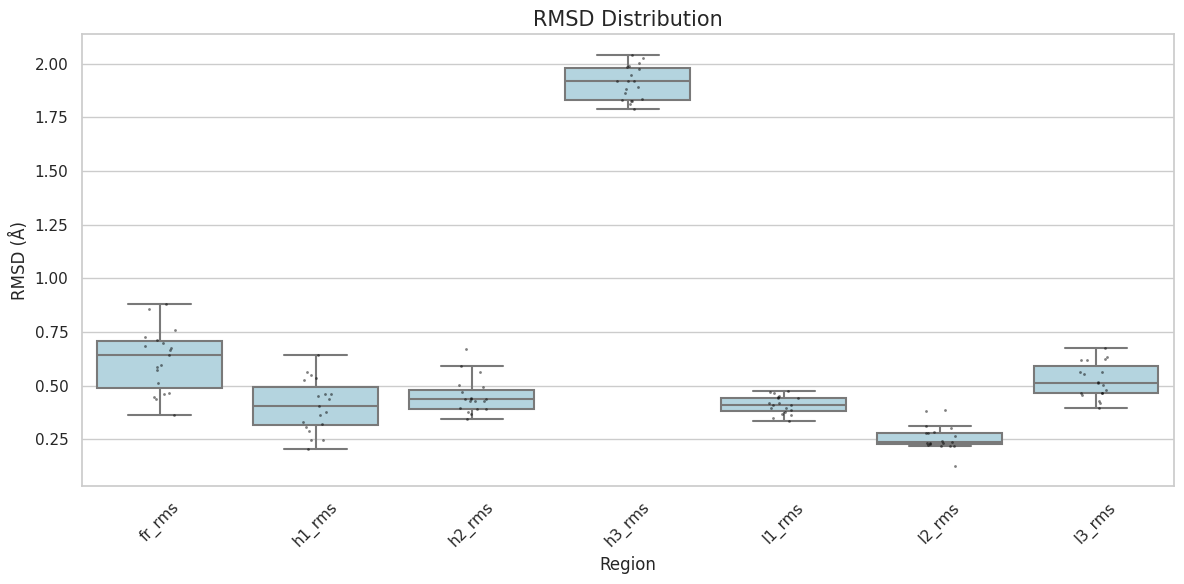

--- Region별 평균 RMSD ---
fr_rms    0.618472
h1_rms    0.406737
h2_rms    0.452167
h3_rms    1.909580
l1_rms    0.411533
l2_rms    0.258108
l3_rms    0.524350
dtype: float64


In [8]:
import os
import glob
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 추출할 키 목록
target_keys = ['fr_rms', 'h1_rms', 'h2_rms', 'h3_rms', 'l1_rms', 'l2_rms', 'l3_rms']

# ---------------------------------------------------------
# 2. 데이터 수집
# ---------------------------------------------------------
# recursive=True를 사용하여 하위 디렉토리까지 모두 검색
file_pattern = os.path.join(root_dir, '**', '*_rmsd.json')
json_files = glob.glob(file_pattern, recursive=True)

data_list = []

print(f"총 {len(json_files)}개의 파일을 찾았습니다. 데이터 로딩 중...")

for filepath in json_files:
    try:
        with open(filepath, 'r') as f:
            content = json.load(f)
            
            # 각 키에 해당하는 값을 추출하여 딕셔너리로 저장
            # 키가 없을 경우 None 처리 (필요시 0이나 NaN으로 변경 가능)
            row = {key: content.get(key) for key in target_keys}
            
            # 파일 출처를 알고 싶다면 아래 주석 해제
            # row['filename'] = os.path.basename(filepath)
            
            data_list.append(row)
    except Exception as e:
        print(f"Error reading {filepath}: {e}")

# ---------------------------------------------------------
# 3. 데이터프레임 변환 및 전처리 (Melting)
# ---------------------------------------------------------
df = pd.read_json(json.dumps(data_list)) # 혹은 pd.DataFrame(data_list)

# Seaborn으로 그리기 좋게 Wide Format -> Long Format으로 변경
# 예: 컬럼이 [Region, RMSD] 형태가 되도록 변환
df_melted = df.melt(var_name='Region', value_name='RMSD')

# 결측치(None/NaN) 제거 (그래프 에러 방지)
df_melted = df_melted.dropna()

# ---------------------------------------------------------
# 4. 시각화 (Boxplot + Strip plot)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid") # 배경 스타일 설정

# 4-1. Boxplot 그리기 (이상치 점은 숨김: showfliers=False, 포인트가 겹치므로)
sns.boxplot(
    x='Region', 
    y='RMSD', 
    data=df_melted, 
    color='lightblue',   # 박스 색상
    showfliers=False     # 박스플롯 자체의 outlier 점은 숨김 (아래 stripplot으로 대체)
)

# 4-2. 데이터 포인트(Jitter) 그리기
sns.stripplot(
    x='Region', 
    y='RMSD', 
    data=df_melted, 
    color='black',       # 점 색상
    alpha=0.5,           # 투명도 (점들이 겹칠 때 유용)
    jitter=True,         # 점들이 겹치지 않게 좌우로 흩뿌림
    size=2               # 점 크기
)

plt.title('RMSD Distribution', fontsize=15)
plt.ylabel('RMSD (Å)', fontsize=12)
plt.xlabel('Region', fontsize=12)
plt.xticks(rotation=45) # x축 라벨이 길 경우 기울이기

plt.tight_layout()
plt.show()

# (선택사항) 평균값 등의 통계 확인
print("--- Region별 평균 RMSD ---")
print(df.mean())

## Select samples by pLDDT

In [14]:
selected_cdrs = [
    "fr"
]

rmsd_threshold = {
    "fr": 0.1
}


In [15]:
import os
import json
from glob import glob

def read_json(path):
    with open(path, "r") as f:
        return json.load(f)


# cdr -> list of (plddt, rmsd, rmsd_json_path)
results = {cdr: [] for cdr in selected_cdrs}

# 모든 *_rmsd.json 수집
rmsd_jsons = glob(os.path.join(root_dir, "**", "*_rmsd.json"), recursive=True)

for rmsd_json_path in rmsd_jsons:
    rmsd_data = read_json(rmsd_json_path)

    # 대응되는 plddt json 경로 만들기
    base = os.path.basename(rmsd_json_path)
    plddt_name = base.replace("_rmsd.json", "_plddts.json")

    parent_dir = os.path.dirname(rmsd_json_path)
    plddt_json_path = os.path.join(parent_dir, "plddt", plddt_name)

    plddt_data = read_json(plddt_json_path)


    for cdr in selected_cdrs:

        rmsd_val = rmsd_data[cdr+"_rms"]
        if cdr == 'fr':
            plddt_val = plddt_data["h3_aa"]
        else:
            plddt_val = plddt_data[cdr+"_aa"]

        # threshold 적용
        if rmsd_val <= rmsd_threshold[cdr]:
            continue
        if rmsd_val >= 3:
            continue
        results[cdr].append(
            (plddt_val, rmsd_val, rmsd_json_path)
        )


# ---------------------------------------------------------
# plddt 기준으로 상위 10개 추리기
# ---------------------------------------------------------

top10_per_cdr = {}

for cdr, items in results.items():

    # plddt 내림차순
    items_sorted = sorted(items, key=lambda x: x[0], reverse=True)

    top10_per_cdr[cdr] = items_sorted[:30]


# ---------------------------------------------------------
# 출력
# ---------------------------------------------------------

for cdr in selected_cdrs:
    print(f"\n===== {cdr} =====")

    for rank, (plddt, rmsd, path) in enumerate(top10_per_cdr[cdr], 1):
        print(f"{rank:2d}  plddt={plddt:.4f}  rmsd={rmsd:.4f}  {os.path.basename(path)}")



===== fr =====
 1  plddt=89.9271  rmsd=0.5137  gkr01i_FA29I_sample_0_rmsd.json
 2  plddt=89.9096  rmsd=0.6837  gkr01i_FA29I_sample_3_rmsd.json
 3  plddt=89.9039  rmsd=0.4673  gkr01i_FA29I_sample_1_rmsd.json
 4  plddt=89.8724  rmsd=0.5981  gkr01i_sample_0_rmsd.json
 5  plddt=89.8662  rmsd=0.7608  gkr01i_FA29I_sample_2_rmsd.json
 6  plddt=89.8658  rmsd=0.8586  gkr01i_sample_2_rmsd.json
 7  plddt=89.8577  rmsd=0.3615  gkr01i_sample_3_rmsd.json
 8  plddt=89.8507  rmsd=0.5871  gkr01i_sample_4_rmsd.json
 9  plddt=89.8187  rmsd=0.6746  gkr01i_sample_1_rmsd.json
10  plddt=88.9024  rmsd=0.4363  gkr01i_FA29H_sample_1_rmsd.json
11  plddt=88.8973  rmsd=0.7128  gkr01i_FA29H_sample_3_rmsd.json
12  plddt=88.8838  rmsd=0.4491  gkr01i_FA29H_sample_4_rmsd.json
13  plddt=88.8318  rmsd=0.8811  gkr01i_FA29H_sample_2_rmsd.json
14  plddt=88.8081  rmsd=0.5720  gkr01i_FA29H_sample_0_rmsd.json
15  plddt=87.7110  rmsd=0.6441  gkr01i_FA29G_sample_4_rmsd.json
16  plddt=87.6967  rmsd=0.6655  gkr01i_FA29G_sample_2_